In [1]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA   
import plotly.express as px
import joblib
import json
import random
random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
df = pd.read_csv(r'../data/IISS_score.csv')
df.shape

(908, 38)

In [3]:
df.head(2)

,patient_id,num_head_hit_location,headhit_not_sure,headhit_neck,headhit_top_of_head,headhit_left_side_of_head,headhit_front_of_head,headhit_back_of_head,headhit_all,headhit_whiplash,headhit_right_side_of_head,imm_symp_light_sensitivity,imm_symp_headache,imm_symp_dazed_or_vacant_stare,imm_symp_dizziness,imm_symp_disorientation,imm_symp_nausea,imm_symp_confusion,imm_symp_coma,imm_symp_incoherent_speech,imm_symp_memory_loss,imm_symp_loss_of_consciousness,event_desc_car,event_desc_fall,event_desc_severe,injury_from_accident,injury_from_fall,injury_from_collision,injury_from_sports,injury_from_assault,injury_from_stroke,injury_from_surgery,age_tbi,gender_male,gender_other,predict_imm_symp_loss_of_consciousness,predict_imm_symp_coma,IISS
0,5c96ba1a-8b2d-49bc-8e8e-b07761948286,6,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.577181,False,False,0.881454,0.001113,0.406434
1,eda39327-b38f-41de-a46a-8782787369b7,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.456376,True,False,0.781812,0.348142,0.358529


In [4]:
df.columns

Index(['patient_id', 'num_head_hit_location', 'headhit_not_sure',
       'headhit_neck', 'headhit_top_of_head', 'headhit_left_side_of_head',
       'headhit_front_of_head', 'headhit_back_of_head', 'headhit_all',
       'headhit_whiplash', 'headhit_right_side_of_head',
       'imm_symp_light_sensitivity', 'imm_symp_headache',
       'imm_symp_dazed_or_vacant_stare', 'imm_symp_dizziness',
       'imm_symp_disorientation', 'imm_symp_nausea', 'imm_symp_confusion',
       'imm_symp_coma', 'imm_symp_incoherent_speech', 'imm_symp_memory_loss',
       'imm_symp_loss_of_consciousness', 'event_desc_car', 'event_desc_fall',
       'event_desc_severe', 'injury_from_accident', 'injury_from_fall',
       'injury_from_collision', 'injury_from_sports', 'injury_from_assault',
       'injury_from_stroke', 'injury_from_surgery', 'age_tbi', 'gender_male',
       'gender_other', 'predict_imm_symp_loss_of_consciousness',
       'predict_imm_symp_coma', 'IISS'],
      dtype='object')

In [5]:
# Step 1: Select features
features = df.drop(columns=["patient_id", "imm_symp_loss_of_consciousness", "imm_symp_coma"])  # your full DataFrame
X = features.copy()

In [6]:
# Step 2: Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
joblib.dump(scaler, '../artifacts/scaler_kmeans.pkl')

In [ ]:
# #  Save the feature order used for training
# feature_order_path = f"../artifacts/features_kmeans.json"
# with open(feature_order_path, "w") as f:
#     json.dump(list(X.columns), f)

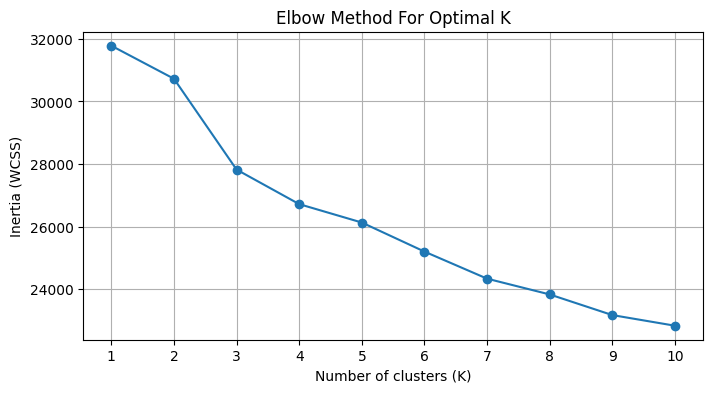

In [9]:
# Calculate inertia for K values
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method For Optimal K')
plt.grid(True)
plt.xticks(K_range)
plt.show()

In [10]:
# Step 2: Apply KMeans with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

In [26]:
joblib.dump(kmeans, "../artifacts/kmeans_iiss.pkl")

['../artifacts/kmeans_iiss.pkl']

In [11]:
from sklearn.metrics import silhouette_score
silhouette_score(X_scaled, kmeans.labels_)

np.float64(0.07816055150296146)

In [12]:
CLUSTER_LABELS = { 0: "Severe", 2: "Mild", 1: "Moderate"}
df['cluster'] = df['cluster'].map(CLUSTER_LABELS)

In [13]:
import plotly.express as px
from sklearn.decomposition import PCA

# Step 3: Reduce to 3 components with PCA
pca = PCA(n_components=3)
pca_result = pca.fit_transform(X_scaled)
df["PCA1"] = pca_result[:, 0]
df["PCA2"] = pca_result[:, 1]
df["PCA3"] = pca_result[:, 2]

# Step 4: 3D Visualization with Custom Cluster Colors
fig = px.scatter_3d(
    df,
    x='PCA1',
    y='PCA2',
    z='PCA3',
    color='cluster',
    color_discrete_map={
        'Mild': 'green',
        'Moderate': 'orange',
        'Severe': 'red'
    },
    hover_data=['patient_id', 'IISS'],
    title='3D Clustering of Patient Phenotypes (K=3)',
)

fig.update_traces(marker=dict(size=5))
fig.update_layout(legend_title_text='Cluster')
fig.show()


In [14]:
fig.write_html("../artifacts/kmeans_cluster_3d.html")

In [15]:
df['cluster'].value_counts()

cluster
Moderate    408
Mild        358
Severe      142
Name: count, dtype: int64

In [17]:
df.head()

,patient_id,num_head_hit_location,headhit_not_sure,headhit_neck,headhit_top_of_head,headhit_left_side_of_head,headhit_front_of_head,headhit_back_of_head,headhit_all,headhit_whiplash,headhit_right_side_of_head,imm_symp_light_sensitivity,imm_symp_headache,imm_symp_dazed_or_vacant_stare,imm_symp_dizziness,imm_symp_disorientation,imm_symp_nausea,imm_symp_confusion,imm_symp_coma,imm_symp_incoherent_speech,imm_symp_memory_loss,imm_symp_loss_of_consciousness,event_desc_car,event_desc_fall,event_desc_severe,injury_from_accident,injury_from_fall,injury_from_collision,injury_from_sports,injury_from_assault,injury_from_stroke,injury_from_surgery,age_tbi,gender_male,gender_other,predict_imm_symp_loss_of_consciousness,predict_imm_symp_coma,IISS,cluster,PCA1,PCA2,PCA3
0,5c96ba1a-8b2d-49bc-8e8e-b07761948286,6,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.577181,False,False,0.881454,0.001113,0.406434,Moderate,2.142883,0.301117,-0.573147
1,eda39327-b38f-41de-a46a-8782787369b7,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.456376,True,False,0.781812,0.348142,0.358529,Moderate,1.670629,-1.038045,-0.422339
2,6a7f7ce9-f63e-4651-b941-a25ce116de74,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.704698,False,False,0.561387,0.000033,0.326011,Moderate,0.605876,1.033234,-0.169429
3,096d402a-5fcd-41dd-b59b-b3089cf06742,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.536913,True,False,0.282775,0.005387,0.264899,Mild,-1.874618,-0.409997,0.373485
4,a419b210-7615-40ac-ad05-a9e0a83046af,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.563758,False,False,0.471963,0.000090,0.293189,Moderate,-0.755911,1.937386,-0.433729


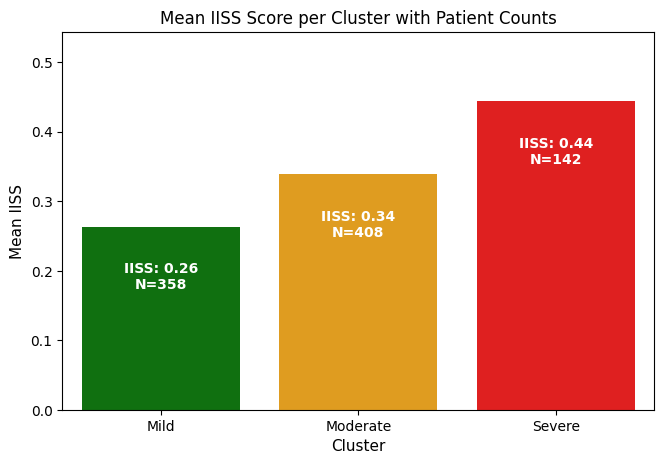

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Step 1: Calculate mean IISS and patient count per cluster
iiss_means = df.groupby("cluster")["IISS"].mean().reset_index()
patient_counts = df.groupby("cluster")["patient_id"].nunique().reset_index()
patient_counts.columns = ["cluster", "patient_count"]

# Merge
iiss_summary = pd.merge(iiss_means, patient_counts, on="cluster")


# Fix: Use same column for hue and x
plt.figure(figsize=(7, 5))
barplot = sns.barplot(
    data=iiss_summary,
    x="cluster",
    y="IISS",
    hue="cluster",
    palette={
        'Mild': 'green',
        'Moderate': 'orange',
        'Severe': 'red'
    },
    legend=False
)

# Add text inside bar
for index, row in iiss_summary.iterrows():
    barplot.text(
        x=index,
        y=row["IISS"] - 0.05,  # shift slightly inside
        s=f'IISS: {row["IISS"]:.2f}\nN={row["patient_count"]}',
        ha='center',
        va='top',
        fontsize=10,
        fontweight='bold',
        color='white'
    )

plt.title("Mean IISS Score per Cluster with Patient Counts", fontsize=12)
plt.xlabel("Cluster", fontsize=11)
plt.ylabel("Mean IISS", fontsize=11)
plt.ylim(0, iiss_summary["IISS"].max() + 0.1)  # Make sure space for label
plt.tight_layout(pad=2.0)  # Add extra padding
plt.show()


C:\Users\rohit\AppData\Local\Temp\ipykernel_36716\4103484667.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




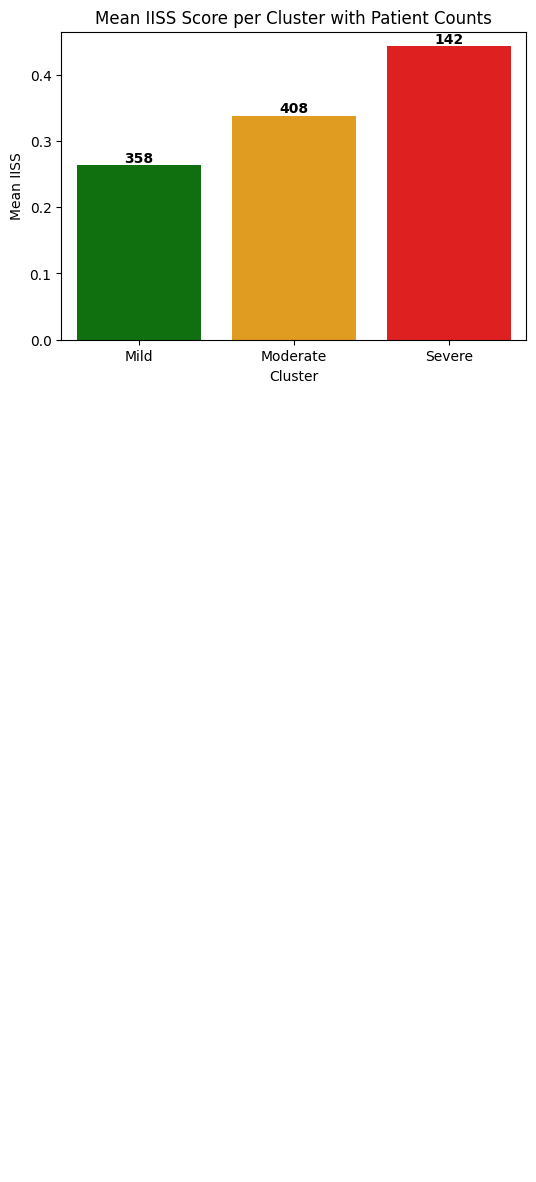

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Mean IISS and patient count per cluster
iiss_means = df.groupby("cluster")["IISS"].mean().reset_index()
patient_counts = df.groupby("cluster")["patient_id"].nunique().reset_index()
patient_counts.columns = ["cluster", "patient_count"]

# Step 2: Merge mean IISS and patient counts
iiss_summary = pd.merge(iiss_means, patient_counts, on="cluster")

# Step 3: Define custom color mapping
custom_palette = {
    'Mild': 'green',
    'Moderate': 'orange',
    'Severe': 'red'
}

# Step 4: Plot mean IISS per cluster with custom colors and value labels
plt.figure(figsize=(6, 4))
barplot = sns.barplot(
    data=iiss_summary,
    x="cluster",
    y="IISS",
    palette=custom_palette
)

# Step 5: Add both IISS and patient count labels
for index, row in iiss_summary.iterrows():
    barplot.text(
        x=index,
        y=row["IISS"] - 1.5,  # IISS label slightly inside the bar
        s=f'{row["IISS"]:.2f}',
        ha='center',
        va='top',
        fontweight='bold',
        color='white'
    )
    barplot.text(
        x=index,
        y=row["IISS"],  # Patient count label above the bar
        s=f'{row["patient_count"]}',
        ha='center',
        va='bottom',
        fontweight='bold',
        color='black'
    )

plt.title("Mean IISS Score per Cluster with Patient Counts")
plt.xlabel("Cluster")
plt.ylabel("Mean IISS")
# plt.tight_layout()
plt.show()


In [25]:
df.columns

Index(['patient_id', 'num_head_hit_location', 'headhit_not_sure',
       'headhit_neck', 'headhit_top_of_head', 'headhit_left_side_of_head',
       'headhit_front_of_head', 'headhit_back_of_head', 'headhit_all',
       'headhit_whiplash', 'headhit_right_side_of_head',
       'imm_symp_light_sensitivity', 'imm_symp_headache',
       'imm_symp_dazed_or_vacant_stare', 'imm_symp_dizziness',
       'imm_symp_disorientation', 'imm_symp_nausea', 'imm_symp_confusion',
       'imm_symp_coma', 'imm_symp_incoherent_speech', 'imm_symp_memory_loss',
       'imm_symp_loss_of_consciousness', 'event_desc_car', 'event_desc_fall',
       'event_desc_severe', 'injury_from_accident', 'injury_from_fall',
       'injury_from_collision', 'injury_from_sports', 'injury_from_assault',
       'injury_from_stroke', 'injury_from_surgery', 'age_tbi', 'gender_male',
       'gender_other', 'predict_imm_symp_loss_of_consciousness',
       'predict_imm_symp_coma', 'IISS', 'cluster', 'PCA1', 'PCA2', 'PCA3'],
      dtype